# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

In [3]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [4]:
# Turn this up at your own risk! 10_000 is safe..

MAXIMUM_DATAPOINTS = 10_000

In [5]:
DB = "products_vectorstore"
client = chromadb.PersistentClient(path=DB)

In [6]:
collection = client.get_or_create_collection('products')

In [7]:
CATEGORIES = ['Appliances', 'Automotive', 'Cell_Phones_and_Accessories', 'Electronics','Musical_Instruments', 'Office_Products', 'Tools_and_Home_Improvement', 'Toys_and_Games']
COLORS = ['red', 'blue', 'brown', 'orange', 'yellow', 'green' , 'purple', 'cyan']

In [8]:
# Prework
result = collection.get(include=['embeddings', 'documents', 'metadatas'], limit=MAXIMUM_DATAPOINTS)
vectors = np.array(result['embeddings'])
documents = result['documents']
categories = [metadata['category'] for metadata in result['metadatas']]
colors = [COLORS[CATEGORIES.index(c)] for c in categories]

In [9]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42, n_jobs=-1)
reduced_vectors = tsne.fit_transform(vectors)

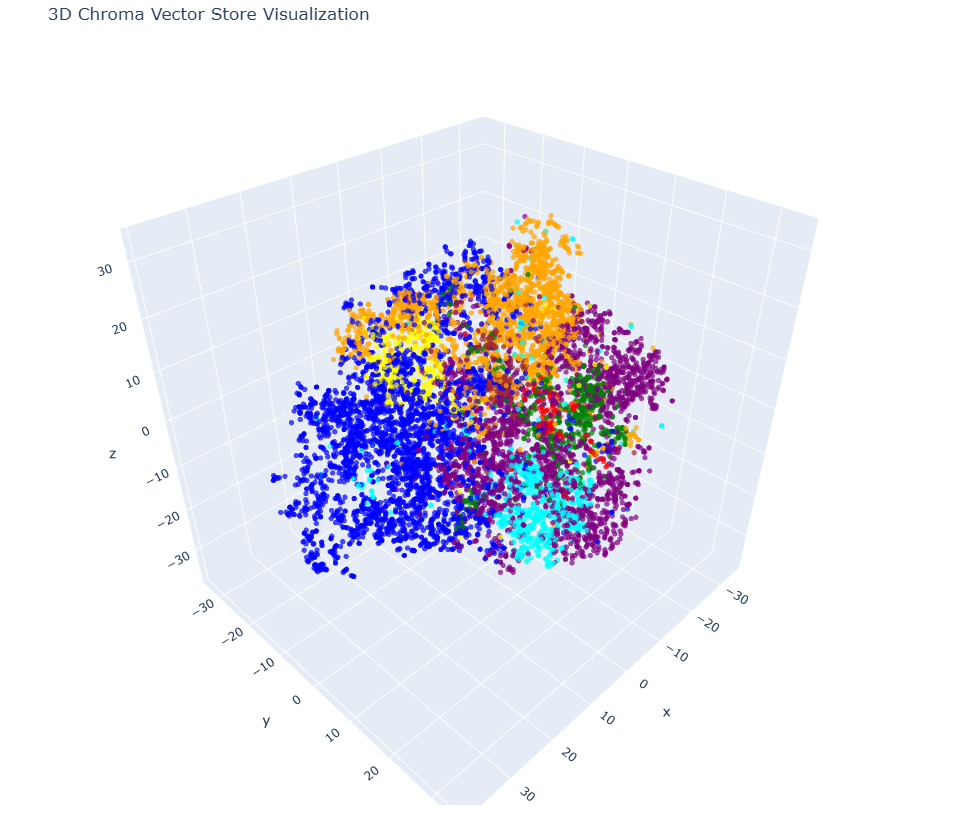

In [10]:

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=3, color=colors, opacity=0.7),
    text=categories,  # Her noktanın kategorisini ekledik
    hoverinfo='text'  # Hoverda sadece metin göster
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [11]:
import numpy as np
from collections import Counter, defaultdict
import csv
from typing import List, Dict, Tuple

def analyze_neighbor_consistency(
    categories: List[str],
    documents: List[str],
    vectors_highdim: np.ndarray = None,
    vectors_lowdim: np.ndarray = None,
    k: int = 5,
    min_same_ratio: float = 0.6,
    use_original_space: bool = True,
    export_csv_path: str = None
) -> Dict:
    """
    Komşuluk tabanlı kategori tutarlılığı analizi.
    
    Args:
        categories: Her veri noktası için kategori etiketi (len = N).
        documents: Her veri noktası için metin/doküman (len = N).
        vectors_highdim: Orijinal embedding uzayı (N x D) — önerilen.
        vectors_lowdim: t-SNE/UMAP vs. düşük boyutlu uzay (N x d).
        k: Kaç komşu bakılacak (kendisi hariç).
        min_same_ratio: 'k' komşunun en az bu oranı aynı kategori değilse şüpheli say.
        use_original_space: True ise vectors_highdim, False ise vectors_lowdim kullan.
        export_csv_path: Şüpheli örnekleri CSV’ye yazmak için yol (veya None).
        
    Returns:
        result: {
          'N': int,
          'flagged_count': int,
          'flagged_ratio': float,
          'by_category': Dict[str, int],
          'confusion_pairs': List[('TrueCat|NeighborCat', count)...],
          'samples': List[ dict(index, true_cat, neighbor_cats, doc_preview) ]
        }
    """
    # Hangi uzay kullanılacak?
    if use_original_space:
        if vectors_highdim is None:
            raise ValueError("use_original_space=True seçildi ama vectors_highdim=None.")
        X = vectors_highdim
    else:
        if vectors_lowdim is None:
            raise ValueError("use_original_space=False seçildi ama vectors_lowdim=None.")
        X = vectors_lowdim

    N = len(categories)
    if X.shape[0] != N or len(documents) != N:
        raise ValueError("Uzay, categories ve documents uzunlukları uyuşmuyor.")

    # Mesafe matrisi hesaplamak pahalı olabilir; satır satır ilerleyelim.
    flagged = []
    by_category = Counter()
    confusion_pair_counter = Counter()

    # Küçük performans optimizasyonu için L2 norm ön-hesabı (cosine istersen güncelleyebilirsin)
    # Şimdilik Öklid mesafesi:
    for i in range(N):
        # Mesafeleri hesapla
        diffs = X - X[i]
        dists = np.einsum('ij,ij->i', diffs, diffs) ** 0.5  # euclidean
        nn_idx = np.argsort(dists)[1:k+1]  # kendisini atla (0. sırada)
        
        true_cat = categories[i]
        neighbor_cats = [categories[j] for j in nn_idx]
        same_count = sum(1 for c in neighbor_cats if c == true_cat)
        same_ratio = same_count / k

        # Komşuların çoğunluğu aynı kategori değilse şüpheli
        if same_ratio < min_same_ratio:
            flagged.append({
                "index": i,
                "true_category": true_cat,
                "neighbor_categories": neighbor_cats,
                "same_ratio": round(same_ratio, 3),
                "doc_preview": (documents[i] or "")[:120].replace("\n", " ")
            })
            by_category[true_cat] += 1
            # Hangi kategori ile karışıyor? En çok görünen komşu kategoriyi say
            top_neighbor = Counter(neighbor_cats).most_common(1)[0][0]
            if top_neighbor != true_cat:
                confusion_pair_counter[f"{true_cat}|{top_neighbor}"] += 1

    flagged_count = len(flagged)
    result = {
        "N": N,
        "flagged_count": flagged_count,
        "flagged_ratio": round(flagged_count / N, 4),
        "by_category": dict(by_category),
        "confusion_pairs": confusion_pair_counter.most_common(20),
        "samples": flagged[:20]  # ilk 20 örnek
    }

    # CSV'ye dök
    if export_csv_path:
        fieldnames = ["index", "true_category", "neighbor_categories", "same_ratio", "doc_preview"]
        with open(export_csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            for row in flagged:
                row_out = row.copy()
                row_out["neighbor_categories"] = ", ".join(row["neighbor_categories"])
                writer.writerow(row_out)

    return result


In [12]:
# 1) Orijinal embedding uzayında (önerilen – daha gerçekçi)
report = analyze_neighbor_consistency(
    categories=categories,
    documents=documents,
    vectors_highdim=vectors,      # (N x D)
    vectors_lowdim=reduced_vectors,  # yedek olarak da verebilirsin
    k=5,
    min_same_ratio=0.6,
    use_original_space=True,      # orijinal uzayda kontrol
    export_csv_path="suspicious_points.csv"
)

print("Toplam N:", report["N"])
print("Şüpheli sayısı:", report["flagged_count"], "→ oran:", report["flagged_ratio"])
print("Kategoriye göre şüpheli sayıları:", report["by_category"])
print("En sık karışan çiftler:", report["confusion_pairs"])
print("\nÖrnekler:")
for s in report["samples"]:
    print(f"[{s['index']}] {s['true_category']} | same_ratio={s['same_ratio']} | neighbors={s['neighbor_categories']}")
    print("  ", s["doc_preview"])


Toplam N: 10000
Şüpheli sayısı: 758 → oran: 0.0758
Kategoriye göre şüpheli sayıları: {'Cell_Phones_and_Accessories': 38, 'Electronics': 180, 'Tools_and_Home_Improvement': 183, 'Office_Products': 99, 'Automotive': 108, 'Toys_and_Games': 85, 'Musical_Instruments': 49, 'Appliances': 16}
En sık karışan çiftler: [('Tools_and_Home_Improvement|Automotive', 80), ('Automotive|Tools_and_Home_Improvement', 63), ('Electronics|Tools_and_Home_Improvement', 42), ('Office_Products|Tools_and_Home_Improvement', 37), ('Tools_and_Home_Improvement|Electronics', 32), ('Electronics|Cell_Phones_and_Accessories', 26), ('Electronics|Office_Products', 25), ('Electronics|Automotive', 25), ('Electronics|Musical_Instruments', 24), ('Cell_Phones_and_Accessories|Electronics', 22), ('Office_Products|Electronics', 22), ('Toys_and_Games|Tools_and_Home_Improvement', 22), ('Tools_and_Home_Improvement|Office_Products', 21), ('Toys_and_Games|Electronics', 20), ('Automotive|Electronics', 19), ('Office_Products|Toys_and_Games